In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

    House_Area  Number_of_rooms  Price
0         2946                1   1000
1         3366                6   1100
2         3589                8   1200
3         3911                4   1300
4         4276                8   1400
5         4508                4   1500
6         4727               10   1600
7         5130                9   1700
8         5459                5   1800
9         5689                5   1900
10        6035                6   2000
11        6274                8   2100
12        6689                5   2200
13        6873                7   2300
14        7212                3   2400
15        7454                9   2500
Plane equation:
Price = 0.33*House_Area + 0.90*Rooms + -8.41


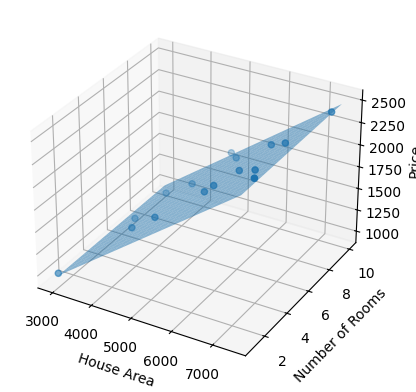

In [6]:
df=pd.read_csv("Assignment_2_GG.csv")
df=df.sort_values(by=["House_Area","Number_of_rooms"]).reset_index(drop=True)
print(df)
df_copy=df.copy()

X = df[["House_Area", "Number_of_rooms"]].values
Y = df["Price"].values

# Add bias column
X = np.c_[np.ones(X.shape[0]), X]

# Normal equation
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

c, a, b = beta
print("Plane equation:")
print(f"Price = {a:.2f}*House_Area + {b:.2f}*Rooms + {c:.2f}")

x_surf = np.linspace(df["House_Area"].min(), df["House_Area"].max(), 20)
y_surf = np.linspace(df["Number_of_rooms"].min(), df["Number_of_rooms"].max(), 20)

x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = a*x_surf + b*y_surf + c

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Scatter points
ax.scatter(df["House_Area"], df["Number_of_rooms"], df["Price"])

# Plane
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)

ax.set_xlabel("House Area")
ax.set_ylabel("Number of Rooms")
ax.set_zlabel("Price")
plt.show()




In [55]:
def multiple_regression(m1_now,m2_now,b_now,data,L):
    m1_slope=0
    m2_slope=0
    b_slope=0
    n=len(data)

    for i in range(n):
        x1=data.iloc[i]["House_Area"]
        x2=data.iloc[i]["Number_of_rooms"]
        y=data.iloc[i]["Price"]

        m1_slope+=-(2/n)*x1*(y-(m1_now*x1+m2_now*x2+b_now))
        m2_slope+=-(2/n)*x2*(y-(m1_now*x1+m2_now*x2+b_now))
        b_slope+=-(2/n)*(y-(m1_now*x1+m2_now*x2+b_now))

    m1=m1_now-m1_slope*L
    m2=m2_now-m2_slope*L
    b=b_now-b_slope*L

    return m1,m2,b


In [56]:
m1=0
m2=0
b=0
L=0.001
iterations=1000

for i in range(iterations):
    m1,m2,b=multiple_regression(m1,m2,b,df,L)

print(m1,m2,b)

print("Enter the house area and number of rooms of the house whose price you want to predict")
HA=int(input("House_Area:"))
HA_norm=(HA-df_Hmean)/(df_Hstd)
R=int(input("Number of rooms:"))
R_norm=(R-df_Rmean)/(df_Rstd)
price_predicted=(m1*HA_norm)+(m2*R_norm)+b
print(f"The predicted price is:{price_predicted}")



397.8744857369503 28.937346830349245 1513.6370857183033
Enter the house area and number of rooms of the house whose price you want to predict
The predicted price is:952.2570550411066
